In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.sample(5)

,review,sentiment
24850,"hair, the movie based on the broadway hit,fail...",negative
41050,I just saw this film in Santa Barbara. My frie...,positive
15109,"Once you can get past the film's title, ""Pecke...",positive
46532,Wow! Here comes another straight-to-video scar...,negative
27957,"Why would a person go back to a person, who ki...",negative


In [4]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [6]:
df.duplicated().sum()

418

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

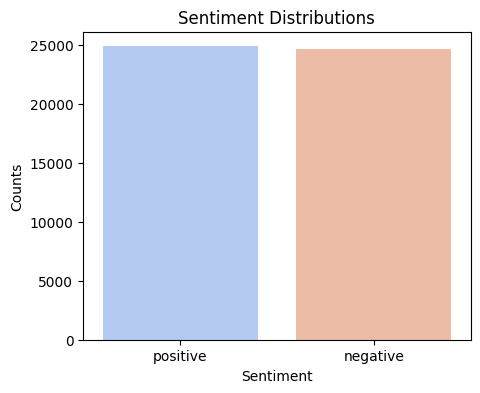

In [9]:
plt.figure(figsize=(5,4))
sns.barplot(df['sentiment'].value_counts(),palette='coolwarm')
plt.xlabel('Sentiment')
plt.ylabel('Counts')
plt.title('Sentiment Distributions')
plt.show()

# Preprocessing

In [10]:
df['review'][8]

"Encouraged by the positive comments about this film on here I was looking forward to watching this film. Bad mistake. I've seen 950+ films and this is truly one of the worst of them - it's awful in almost every way: editing, pacing, storyline, 'acting,' soundtrack (the film's only song - a lame country tune - is played no less than four times). The film looks cheap and nasty and is boring in the extreme. Rarely have I been so happy to see the end credits of a film. <br /><br />The only thing that prevents me giving this a 1-score is Harvey Keitel - while this is far from his best performance he at least seems to be making a bit of an effort. One for Keitel obsessives only."

In [11]:
df['review'] = df['review'].apply(lambda x :x.lower())

In [12]:
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. <br /><br />the...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 49582, dtype: str

In [13]:
import re

In [14]:
df['review'] = df['review'].apply(lambda x : re.sub(r'<.*?>','',str(x)))


In [15]:
import string

In [16]:
def remove_punc(text):
    return text.translate(str.maketrans('','',string.punctuation))

In [17]:
df['review'] = df['review'].apply(remove_punc)

In [18]:
def remove_num(text):
    new=""
    for i in text:
        if not i.isdigit():
            new = new + i

    return new

In [19]:
df['review'] = df['review'].apply(remove_num)

In [20]:
!pip install nltk


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [22]:
stop_words = set(stopwords.words('english'))

In [23]:
def remove(text):
    words = text.split()
    cleaned = []
    for i in words:
        if not i in stop_words:
            cleaned.append(i)

    return ' '.join(cleaned)

In [24]:
df['review'] = df['review'].apply(remove)

In [25]:
import nltk

In [26]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kaman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
df['num_char'] = df['review'].apply(len)

In [28]:
df['num_words'] = df['review'].apply(lambda x: len(nltk.word_tokenize(x)))

In [29]:
df['num_sentence'] = df['review'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [30]:
df.head(5)

,review,sentiment,num_char,num_words,num_sentence
0,one reviewers mentioned watching oz episode yo...,positive,1157,167,1
1,wonderful little production filming technique ...,positive,656,84,1
2,thought wonderful way spend time hot summer we...,positive,587,85,1
3,basically theres family little boy jake thinks...,negative,456,66,1
4,petter matteis love time money visually stunni...,positive,863,125,1


<Axes: xlabel='num_words', ylabel='Density'>

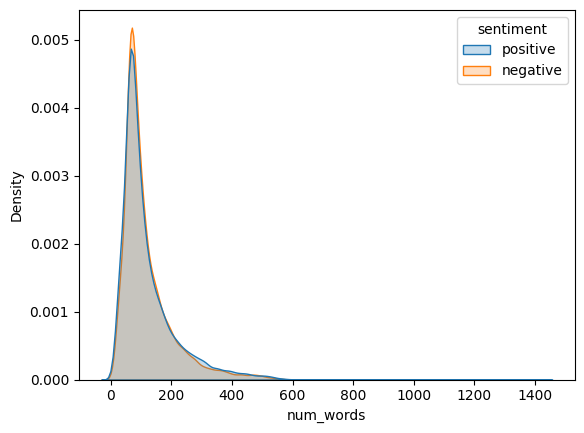

In [31]:
sns.kdeplot(data=df,x='num_words',hue='sentiment',fill=True)

In [32]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [33]:
df['sentiment'] = encoder.fit_transform(df['sentiment'])

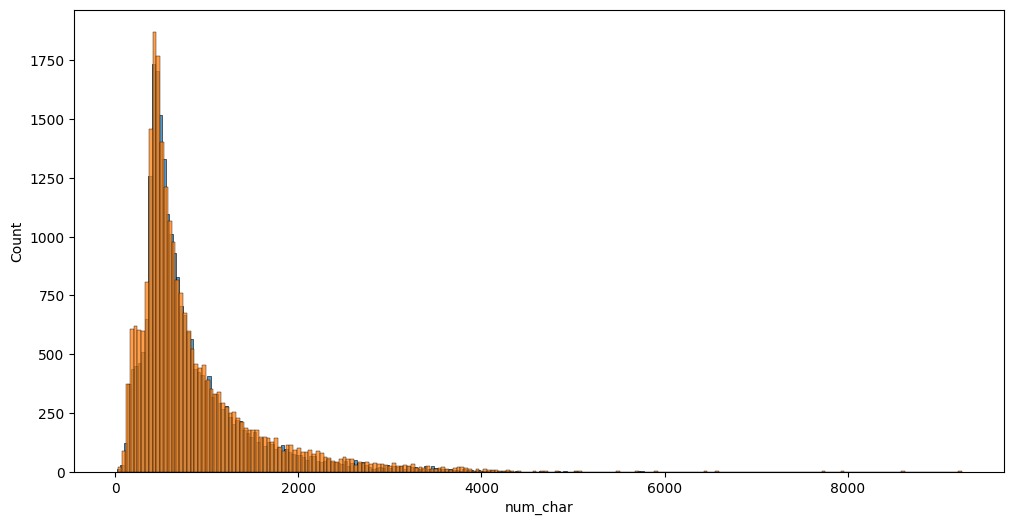

In [34]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['sentiment'] == 0]['num_char'])
sns.histplot(df[df['sentiment'] == 1]['num_char'])
plt.show()

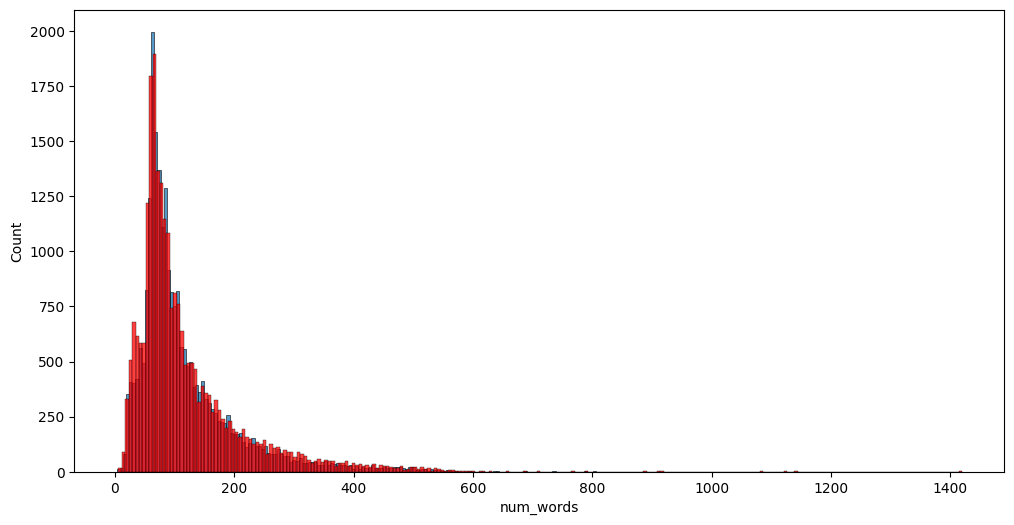

In [35]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['sentiment']==0]['num_words'])
sns.histplot(df[df['sentiment']==1]['num_words'],color='red')
plt.show()

In [36]:
!pip install wordcloud


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')


In [38]:
negative_reviews = wc.generate(df[df['sentiment'] == 0]['review'].str.cat(sep=" "))

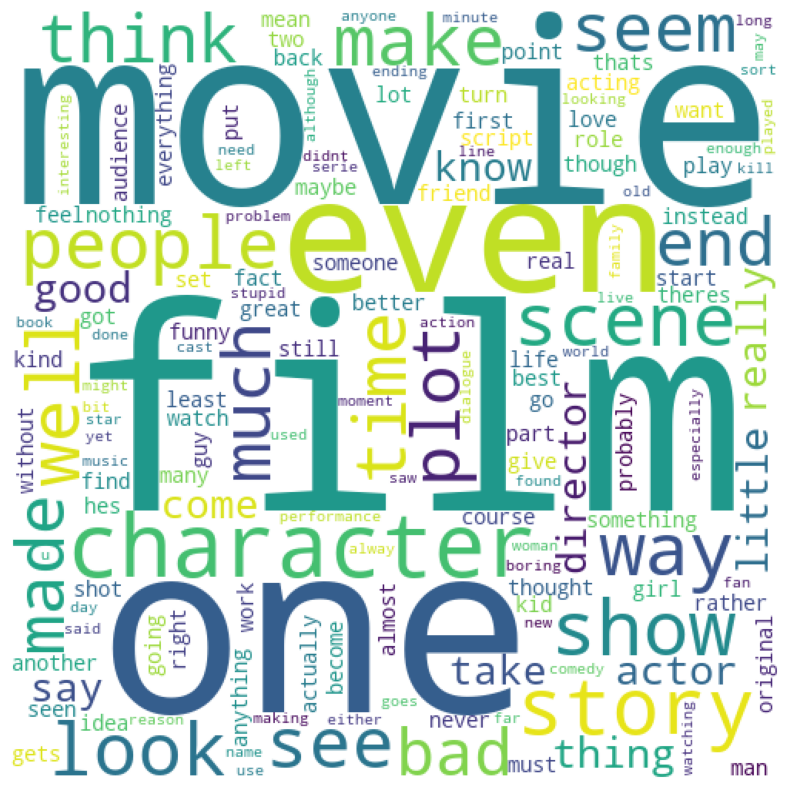

In [39]:
plt.figure(figsize=(12,10))
plt.imshow(negative_reviews.to_image())
plt.axis("off")
plt.show()

In [40]:
positive_reviews = wc.generate(df[df['sentiment'] == 1]['review'].str.cat(sep=" "))


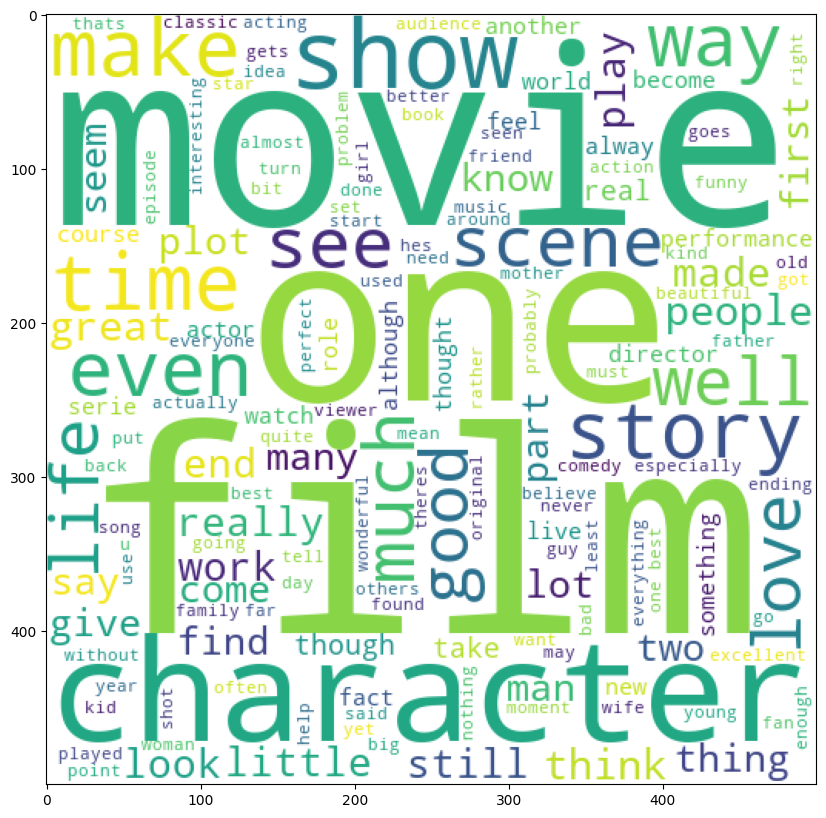

In [41]:
plt.figure(figsize=(12,10))
plt.imshow(positive_reviews.to_image())
plt.show()

# Model Buildings

In [42]:
from sklearn.model_selection import train_test_split

In [49]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=10000)

In [60]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [61]:
X_tf = tfidf.fit_transform(df['review'])

In [62]:
y_tf = df['sentiment']

In [63]:
X_train,X_test,y_train,y_test = train_test_split(X_tf,y_tf,test_size=0.2,random_state=42)

In [70]:
X_tf[:3].toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [72]:
X_tf.shape

(49582, 10000)

In [74]:
y_tf.shape

(49582,)

In [75]:
gnb.fit(X_train.toarray(),y_train)
y_pred_gnb = gnb.predict(X_test.toarray())
print(classification_report(y_test,y_pred_gnb))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79      4939
           1       0.79      0.78      0.78      4978

    accuracy                           0.79      9917
   macro avg       0.79      0.79      0.79      9917
weighted avg       0.79      0.79      0.79      9917



In [76]:
mnb.fit(X_train.toarray(),y_train)
y_pred_mnb = mnb.predict(X_test.toarray())
print(classification_report(y_test,y_pred_mnb))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      4939
           1       0.85      0.86      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



In [77]:
bnb.fit(X_train.toarray(),y_train)
y_pred_bnb = bnb.predict(X_test.toarray())
print(classification_report(y_test,y_pred_bnb))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      4939
           1       0.86      0.84      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



In [78]:
def model_Evaluate(model):
    y_pred = model.predict(X_test)
    
    print(classification_report(y_test,y_pred))
    
    conf_matrix = confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(5,3))
    sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues')

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4939
           1       0.88      0.91      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



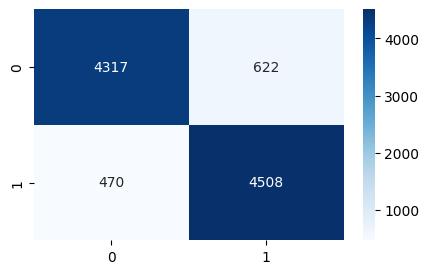

In [79]:
lr = LogisticRegression(max_iter=1000,n_jobs=-1)
lr.fit(X_train,y_train)
model_Evaluate(lr)

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      4939
           1       0.84      0.84      0.84      4978

    accuracy                           0.84      9917
   macro avg       0.84      0.84      0.84      9917
weighted avg       0.84      0.84      0.84      9917



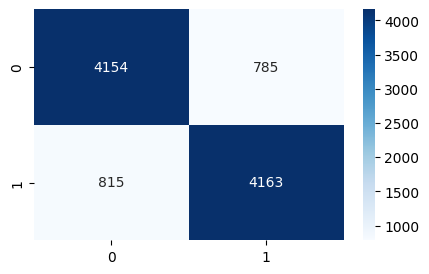

In [80]:
rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)
model_Evaluate(rfc)

In [81]:
import pickle 
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(lr,open('model.pkl','wb'))